In [1]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib inline
%matplotlib widget

In [2]:
def read_time_from_bag(bag, name_topic):
    df = pd.read_csv(bag.message_by_topic(name_topic))
    
    # try to get a time axis; fall back to sample index
    if {'header.stamp.secs', 'header.stamp.nsecs'}.issubset(df.columns):
        t = (df['header.stamp.secs'].to_numpy(dtype=float) +
             df['header.stamp.nsecs'].to_numpy(dtype=float) * 1e-9)
    else:
        print('[Warning] No matching time header found')
        t = np.arange(len(df), dtype=float)

    print(f"read time {name_topic}", t.shape)
    return t

def read_pose_from_bag(bag, name_topic, name_x, name_y):
    df = pd.read_csv(bag.message_by_topic(name_topic))
    
    # try to get a time axis; fall back to sample index
    if {'header.stamp.secs', 'header.stamp.nsecs'}.issubset(df.columns):
        t = (df['header.stamp.secs'].to_numpy(dtype=float) +
             df['header.stamp.nsecs'].to_numpy(dtype=float) * 1e-9)
    else:
        print('[Warning] No matching time header found')
        t = np.arange(len(df), dtype=float)

    pose = np.vstack([df[name_x].to_numpy(), df[name_y].to_numpy()]).T
    print(f"read pose & time {name_topic}", pose.shape)
    return t, pose

def equal_trim_to_match(t1, p1, t2, p2):
    """Evenly downsample the longer sequence to match the shorter length."""
    
    n1, n2 = len(p1), len(p2)
    if n1 == n2:
        return t1, p1, t2, p2
    if n1 > n2:
        idx = np.linspace(0, n1 - 1, n2, dtype=int)
        return t1[idx], p1[idx], t2, p2
    else:
        idx = np.linspace(0, n2 - 1, n1, dtype=int)
        return t1, p1, t2[idx], p2[idx]

In [31]:
# bag = bagreader('/home/henrypcl/mocap_data_analy_2.bag')
bag = bagreader('/Users/henrychang/Desktop/DSR_s_curve_tbot_test/bag/tag_lp_test_01.bag')
print(bag.topic_table)

[INFO]  Data folder /Users/henrychang/Desktop/DSR_s_curve_tbot_test/bag/tag_lp_test_01 already exists. Not creating.
                                   Topics  \
0                                 /rosout   
1                             /rosout_agg   
2                  /tbot162/battery_state   
3                        /tbot162/cmd_vel   
4                  /tbot162/cmd_vel_rc100   
5            /tbot162/controller_log_info   
6                    /tbot162/diagnostics   
7               /tbot162/firmware_version   
8           /tbot162/global_leader_states   
9                            /tbot162/imu   
10                  /tbot162/joint_states   
11                /tbot162/magnetic_field   
12                          /tbot162/odom   
13  /tbot162/robot_pose_ekf/odom_combined   
14                  /tbot162/sensor_state   
15                /tbot162/tag_detections   
16                  /tbot162/version_info   
17                     /tbot162/wheelodom   
18                 /tbot205/

read time /tbot162/tag_detections (1217,)


(0.0, 0.14)

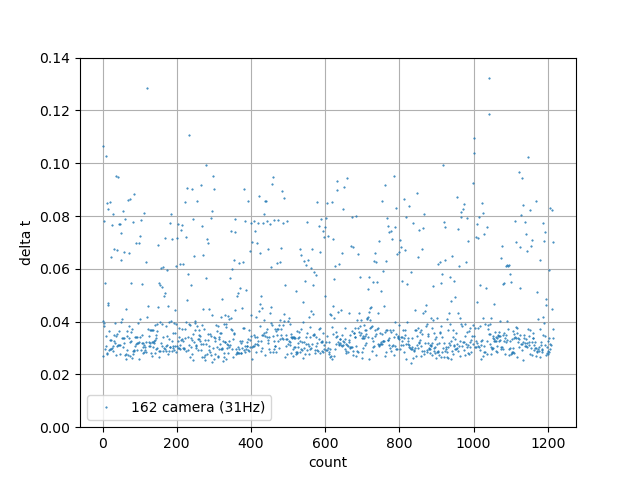

In [63]:
t162_tag = read_time_from_bag(bag, '/tbot162/tag_detections')
plt.figure()
plt.plot(np.diff(t162_tag-t162_tag[0]), '.', markersize='1', label='162 camera (31Hz)')
plt.legend(); plt.grid(); plt.xlabel('count'); plt.ylabel('delta t'); plt.ylim(0, 0.14)

## Leader odom v.s. Follower estimation

read pose & time /vrpn_client_node/bot205/pose (5844, 2)
read pose & time /tbot205/odom (922, 2)
[Warning] No matching time header found
read pose & time /tbot162/global_leader_states (1488, 2)


Text(0, 0.5, 'y')

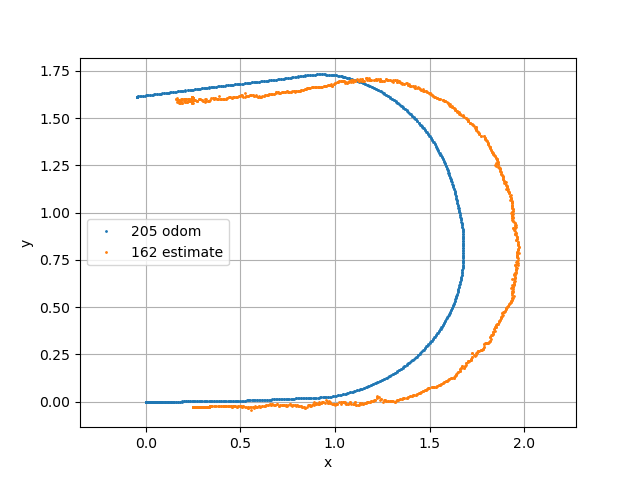

In [35]:
_, pose_205_mocap = read_pose_from_bag(bag,
                                    '/vrpn_client_node/bot205/pose',
                                    'pose.position.x',
                                    'pose.position.y')
_, pose_205_odom = read_pose_from_bag(bag,
                                    '/tbot205/odom',
                                    'pose.pose.position.x',
                                    'pose.pose.position.y')
_, pose_162_estimate = read_pose_from_bag(bag,
                                    '/tbot162/global_leader_states',
                                    'x',
                                    'y')
plt.figure()
# plt.plot(pose_205_mocap[:,0],pose_205_mocap[:,1], '.', markersize='1', label='205 mocap')
plt.plot(pose_205_odom[:,0],pose_205_odom[:,1], '.', markersize='2', label='205 odom')
plt.plot(pose_162_estimate[:,0],pose_162_estimate[:,1], '.', markersize='2', label='162 estimate')
plt.legend(); plt.grid(); plt.axis('equal'); plt.xlabel('x'); plt.ylabel('y')

## Odom v.s. EKF(Odom+IMU)

read pose & time /tbot162/odom (1503, 2)
read pose & time /tbot162/robot_pose_ekf/odom_combined (1558, 2)


(0.0, 0.15)

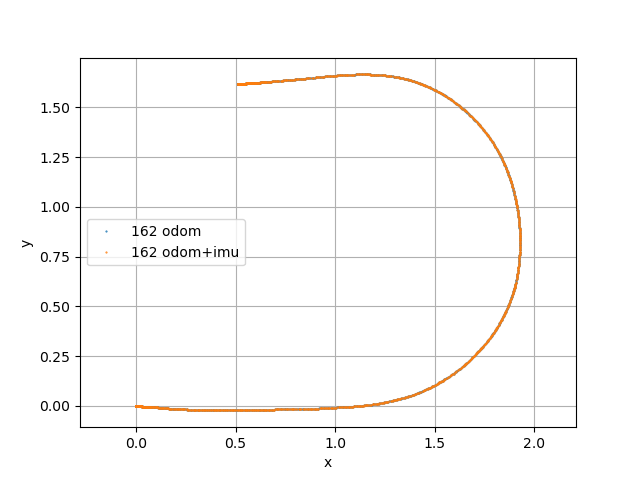

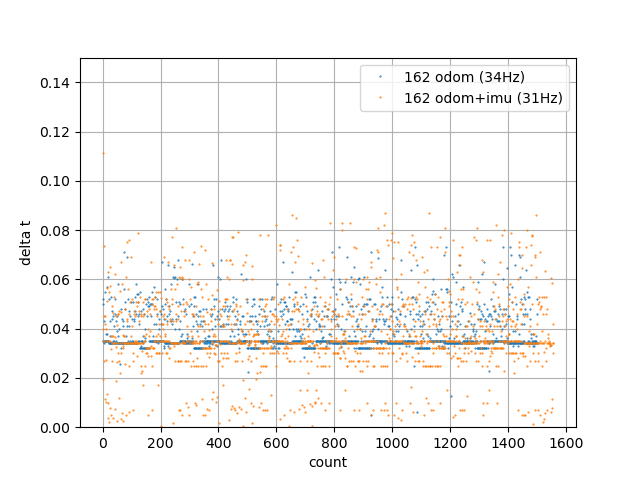

In [34]:
plt.close()

t162, p162_o = read_pose_from_bag(bag,
                                    '/tbot162/odom',
                                    'pose.pose.position.x',
                                    'pose.pose.position.y')
t162_ekf_o, p162_ekf_o = read_pose_from_bag(bag,
                                    '/tbot162/robot_pose_ekf/odom_combined',
                                    'pose.pose.position.x',
                                    'pose.pose.position.y')
plt.figure()
plt.plot(p162_o[:,0],p162_o[:,1], '.', markersize='1', label='162 odom')
plt.plot(p162_ekf_o[:,0],p162_ekf_o[:,1], '.', markersize='1', label='162 odom+imu')
plt.legend(); plt.grid(); plt.axis('equal'); plt.xlabel('x'); plt.ylabel('y')

plt.figure()
plt.plot(np.diff(t162-t162[0]), '.', markersize='1', label='162 odom (34Hz)')
plt.plot(np.diff(t162_ekf_o-t162_ekf_o[0]), '.', markersize='1', label='162 odom+imu (31Hz)')
plt.legend(); plt.grid(); plt.xlabel('count'); plt.ylabel('delta t'); plt.ylim(0, 0.15)

## Velocity Estimation using odom

(0.0, 0.3)

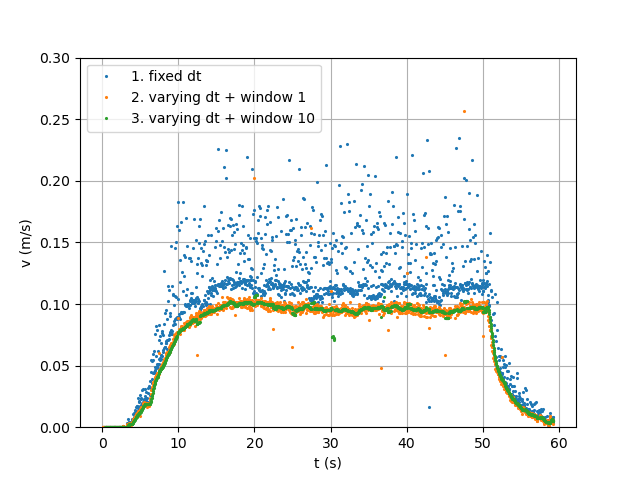

In [78]:
'''
Takeaway: when estimating higher order info, faster is not necessarily better!
'''

def estimate_velocity(pose_array, time, n):
    '''
    pose_array: shape (x, 2)
    time:       shape (x, )
    n:          int, window size
    '''
    return np.linalg.norm(pose_array[n:] - pose_array[:-n], axis=1), time[n:] - time[:-n]

normalize_t = t162-t162[0]

dt_fix = 1/34
dx_1, dt_1 = estimate_velocity(p162_o, normalize_t, n=1)
dx_10, dt_10 = estimate_velocity(p162_o, normalize_t, n=10)
dx_100, dt_100 = estimate_velocity(p162_o, normalize_t, n=100)

plt.figure(); ms = 2.5
plt.plot(normalize_t[1:], dx_1/dt_fix, '.', markersize=ms, label='1. fixed dt')
plt.plot(normalize_t[1:], dx_1/dt_1, '.', markersize=ms, label='2. varying dt + window 1')
plt.plot(normalize_t[10:], dx_10/dt_10, '.', markersize=ms, label='3. varying dt + window 10')
# plt.plot(normalize_t[100:], dx_100/dt_100, '.', markersize=ms, label='4. varying dt + window 100')
plt.grid(); plt.legend(); plt.xlabel('t (s)'); plt.ylabel('v (m/s)'); plt.ylim(0, 0.3)

## Mocap v.s. Camera on spacing error
The goal is to check the camera detection quality

In [26]:
t162, p162_m = read_pose_from_bag(bag,
                                    '/vrpn_client_node/bot162/pose',
                                    'pose.position.x',
                                    'pose.position.y')
t205, p205_m = read_pose_from_bag(bag,
                                    '/vrpn_client_node/bot205/pose',
                                    'pose.position.x',
                                    'pose.position.y')
# trim mocap data to get spacing error
t162_t, p162_t, t205_t, p205_t = equal_trim_to_match(t162, p162_m, t205, p205_m)

read pose & time /vrpn_client_node/bot162/pose (6003, 2)
read pose & time /vrpn_client_node/bot205/pose (6043, 2)


Text(0, 0.5, 'spacing Error')

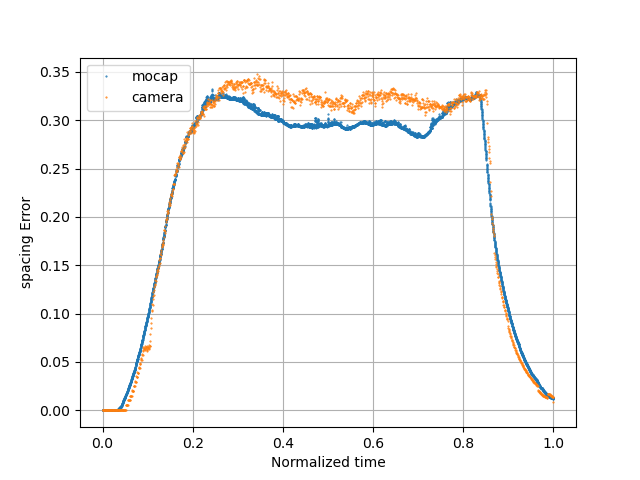

In [12]:
# Spacing error from mocap (0.1)
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time'); plt.ylabel('spacing Error')

Text(0, 0.5, 'spacing Error')

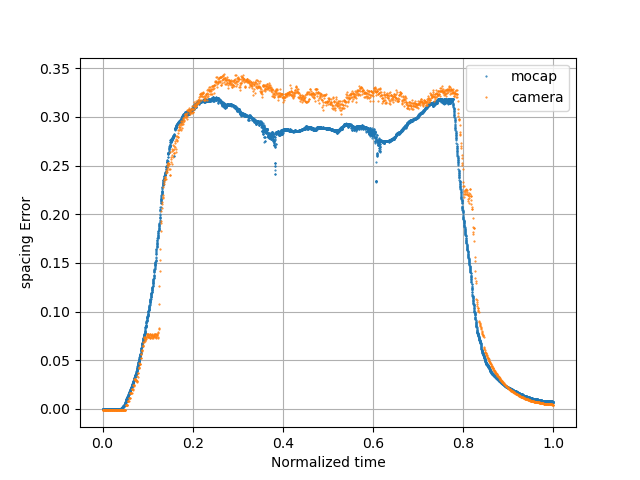

In [21]:
# Spacing error from mocap (0.5)
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time'); plt.ylabel('spacing Error')

Text(0, 0.5, 'spacing Error')

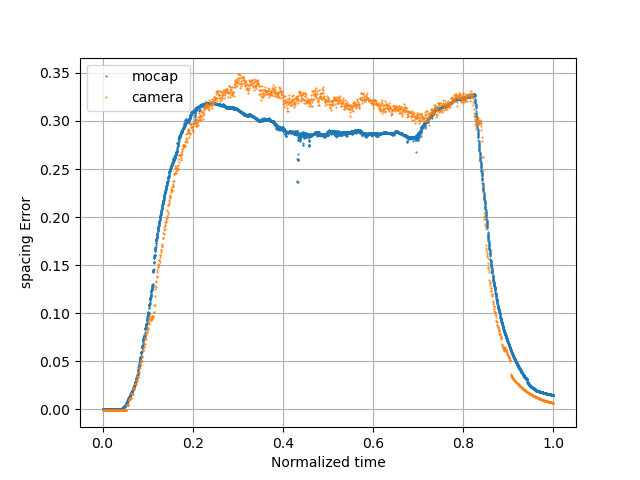

In [24]:
# Spacing error from mocap (0.75)
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time'); plt.ylabel('spacing Error')

Text(0, 0.5, 'spacing Error')

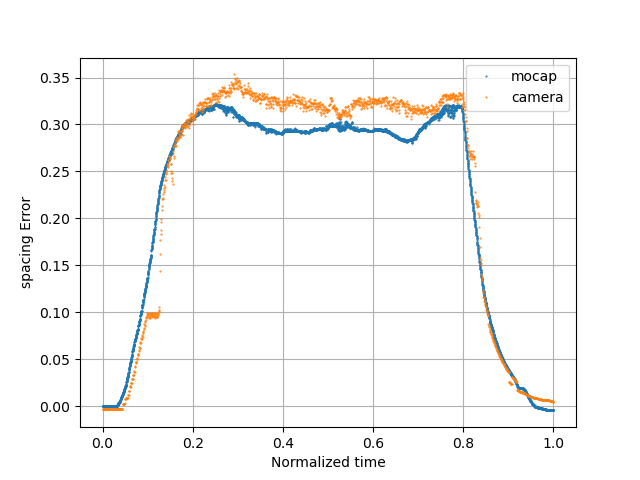

In [27]:
# Spacing error from mocap
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time'); plt.ylabel('spacing Error')


Text(0, 0.5, 'spacing Error')

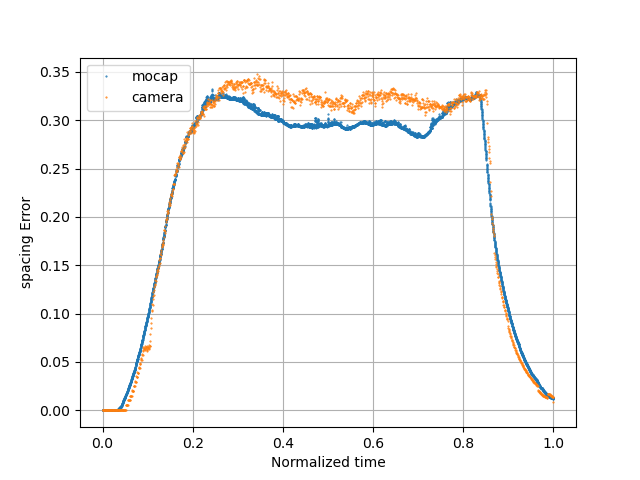

In [16]:
# Spacing error from mocap (old)
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time'); plt.ylabel('spacing Error')
